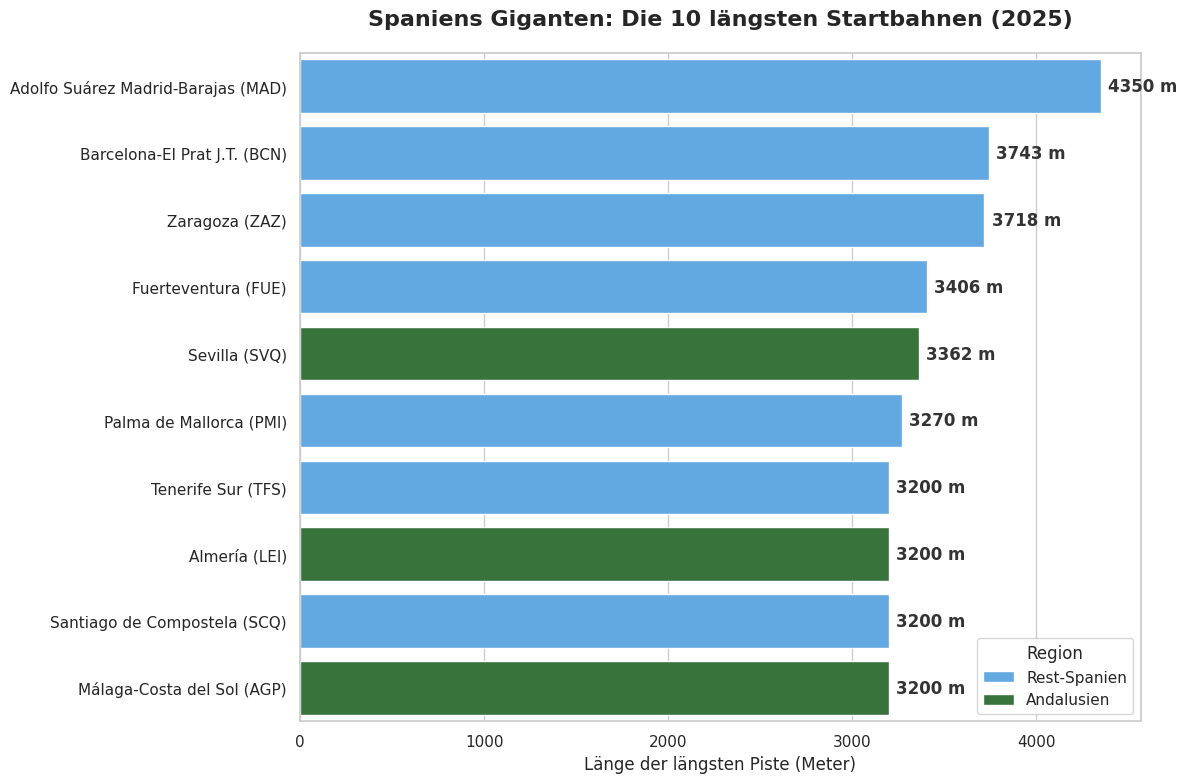

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pymongo import MongoClient

# --- Schritt 1: Verbindung zur MongoDB ---
client = MongoClient("mongodb://localhost:27017/")
db = client.Espana
collection = db.aeropuerto_stats

# Alle Daten für 2025 laden
df = pd.DataFrame(list(collection.find({"jahr": 2025})))

# --- Schritt 2: Daten-Veredelung ---

def get_max_runway_length(row):
    if isinstance(row.get('pistas'), list) and row['pistas']:
        return max(p.get('pistas_largo', 0) for p in row['pistas'])
    return row.get('pistas_largo', 0)

df['max_piste_laenge'] = df.apply(get_max_runway_length, axis=1)

# NEU: Kombinierte Beschriftung erstellen: "Name (IATA)"
df['label_iata'] = df.apply(lambda x: f"{x['aeropuerto']} ({x.get('IATA', '???')})", axis=1)

# Highlight-Logik
df['highlight'] = df['comunidad'].apply(lambda x: 'Andalusien' if x == 'Andalucia' else 'Rest-Spanien')

# Top 10 sortieren
df_top10 = df.sort_values(by='max_piste_laenge', ascending=False).head(10)

# --- Schritt 3: Visualisierung ---

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

my_palette = {'Andalusien': '#2e7d32', 'Rest-Spanien': '#4dabf7'}

chart = sns.barplot(
    data=df_top10,
    x='max_piste_laenge',
    y='label_iata', # Jetzt mit dem kombinierten Label
    palette=my_palette,
    hue='highlight',
    dodge=False
)

plt.title('Spaniens Giganten: Die 10 längsten Startbahnen (2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Länge der längsten Piste (Meter)', fontsize=12)
plt.ylabel('', fontsize=12) # Y-Label leer lassen, da die Namen für sich sprechen
plt.legend(title='Region', loc='lower right')

# Werte direkt an die Balken schreiben
for i, bar in enumerate(chart.patches):
    width = bar.get_width()
    if width > 0:
        plt.text(
            width + 40, 
            bar.get_y() + bar.get_height()/2, 
            f'{int(width)} m', 
            va='center', fontweight='bold', color='#333'
        )

plt.tight_layout()
plt.savefig("top10_pisten_spanien_final.png", dpi=300)
plt.show()